# Cross-sectional commodity value — a quantitative teardown 🔬
### The 5-year value L/S with HAC *t* · a cheap-vs-expensive leg decomposition · a 40-seed random-rank placebo · a sub-period difference test · a cost-and-borrow sweep · a planted-reversal synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Reversal: Refuted](https://img.shields.io/badge/Reversal-Refuted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **Asness-Moskowitz-Pedersen (2013), the commodity value leg: rank on the ratio of the price ~5 years ago to the current price; cheap (fallen) beats expensive (risen)** — is the *long-horizon reversal* sleeve, the deliberate mirror of the 12-1 momentum sort of [792](../../792-commodity-momentum/) on the *same basket*, and the **commodity value leg alone**, not the mixed multi-asset combo of [638](../../638-value-momentum-everywhere/). The job: measure it with an autocorrelation-robust *t*, prove the machinery, and grade it honestly.

> ⚠️ **Data note.** 13 single-commodity ETFs; the value signal reads the **raw price** (`auto_adjust=False`), the P&L the **total-return** close. 2012-12 → 2026-06, 163 monthly rebalances, cached. **Survivorship *and* roll-contamination named on the Signal axis** — both bias the value read upward. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `0524773df8ac`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from commodity_value import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICE = data.monthly_price()
    MRET = data.monthly_returns()
else:
    PRICE = MRET = None
print("real cache present:", HAVE_REAL, "| return panel:",
      (None if MRET is None else f"{MRET.shape[0]} months x {MRET.shape[1]} ETFs"))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'ls_start': '2012-12-31', 'ls_end': '2026-06-30', 'n_months': 163, 'n_etfs': 13, 'price_panel_months': 258, 'ret_panel_months': 220, 'mean_bps': 8.05, 'ann_pct': 0.97, 'hac_t': 0.166, 'hac_lags': 4, 'one_sample_t': 0.18, 'sharpe': 0.049, 'hit_pct': 54.0, 'turnover': 0.31, 'long_bps': -9.88, 'long_t': -0.32, 'short_bps': 17.93, 'short_t': 0.69, 'basket_ann': 1.29, 'placebo_seeds': 40, 'placebo_real_t': 0.166, 'placebo_mean_t': 0.222, 'placebo_sd_t': 1.109, 'placebo_mean_sharpe': 0.059, 'placebo_frac_ge2': 0.075, 'placebo_p': 0.525, 'era_split': '2019-07-01', 'early_n': 79, 'early_bps': 20.92, 'early_t': 0.33, 'early_sharpe': 0.14, 'late_n': 84, 'late_bps': -4.05, 'late_t': -0.06, 'late_sharpe': -0.02, 'diff_t': -0.28, 'timer5_gross': 0.97, 'timer5_net': 0.28, 'timer5_t': 0.05, 'timer5_sharpe': 0.01, 'timer10_gross': 0.97, 'timer10_net': 0.09, 'timer10_t': 0.02, 'timer10_sharpe': 0.0, 'syn_null_mean': -0.23, 'syn_null_sd': 0.97, 'syn_null_fire': 2, 'syn_planted_t': 6.41, 'syn_planted_bps': 257.15, 'syn_planted_sharpe': 1.98, 'fp': '0524773df8ac'}


real cache present: True | return panel: 220 months x 13 ETFs


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | 5-yr value L/S **+8 bps/mo** (~+1.0%/yr, Sharpe 0.05); **HAC t = +0.17**; random-rank placebo p = 0.53 |
| **Tradability** | `MIRAGE` | net +0.1%/yr @10bps (net t = 0.02); gross already ~0 |
| **Reversal direction** | `REFUTED` | cheap (long) leg excess -10 bps/mo (t = -0.32) — *negative* |

> 💡 In plain words: a value premium that is statistically zero, no better than a coin-flip ranking, and whose 'buy the cheap' leg actually *lost* to the basket — the AMP effect does not survive translation to an investable commodity-ETF sort.

## 1 · The claim, steelmanned

Let $P_{i,t}$ be ETF $i$'s **raw price** in month $t$, and $V_{i,t} = \log \bar P_{i,t-60} - \log P_{i,t}$ the **5-year value** signal, where $\bar P_{i,t-60}$ is the average price over the ~4.5–5.5-years-ago band (AMP's reference). A **positive** $V$ means the price fell → the commodity is **cheap**. Each month rank the live assets on $V$, long the cheap top third $C_t$, short the expensive bottom third $E_t$, equal-weight:

$$ R^{LS}_{t+1} = \tfrac{1}{|C_t|}\sum_{i\in C_t} r_{i,t+1} - \tfrac{1}{|E_t|}\sum_{i\in E_t} r_{i,t+1}, $$

where $r$ is the **total-return** monthly return (what a held position earns).

- **H₁ (premium).** $E[R^{LS}] > 0$ with an autocorrelation-robust $t \ge 2$.
- **H₂ (skill, not luck).** $R^{LS}$ beats a random-rank sort of the same basket.
- **H₃ (direction).** The **cheap leg** carries a *positive* excess-of-basket return.
- **H₄ (capture).** It survives realistic costs + short borrow.

We find **H₁ fails** (HAC t = 0.17), **H₂ fails** (placebo p = 0.53), **H₃ fails — points the wrong way** (cheap-leg excess -10 bps/mo), **H₄ moot** (gross ≈ 0).

## 2 · So what? — inference design

Monthly L/S factor returns are **serially correlated**, so the primary statistic is a **Newey-West (HAC)** *t* on the monthly mean with an automatic Bartlett lag — an i.i.d. SE would overstate significance. The value signal reads the **raw price level**, not total return, so five years of accumulated carry/roll cannot masquerade as 'cheapness'. The **one execution lag** is explicit: weights formed at the close of month *t* earn month *t*+1 (a single `shift`). The random-rank **placebo (40 seeds)** holds basket breadth fixed and asks how often noise ranks match the real *t*. The sub-period split (2019-07, the effective-sample midpoint) is tested as a **difference** (Welch *t*). Costs are **one-way × traded notional**; the short leg pays borrow.

## 3 · How we'd know — the protocol

- **Panel.** 13 single-commodity ETFs; a 258-month raw-price panel feeds the signal, a 220-month total-return panel the P&L; the L/S trades **163 months** (2012-12-31 → 2026-06-30) once ≥ 6 names carry a full 5-year price history.
- **Headline.** HAC *t* + one-sample *t* + annualised Sharpe on the monthly L/S.
- **Decomposition.** Cheap and expensive legs, each excess-of-basket, HAC-*t*'d — the direction check.
- **Placebo.** 40-seed random-rank null; p = share of seeds with t ≥ real t.
- **Persistence.** Pre/post-2019 HAC *t* + a Welch *t* of the difference.
- **Execution.** Cost sweep (5 / 10 bps one-way × turnover) + 50 bps/yr short borrow.
- **Control.** Synthetic random-walk price panel with a plantable reversal `val_edge`; the null (edge = 0) must not systematically fire across 20 seeds.

## 4 · The teardown

### 4a · The headline L/S and its placebo

The 5-year value book's HAC *t*, and where it sits against 40 random-rank sorts of the same basket.

L/S: +8.05 bps/mo (~+0.97%/yr) over 163 months
HAC t = +0.166 (4 lags) | one-sample t = +0.180 | Sharpe +0.049 | hit 54.0%


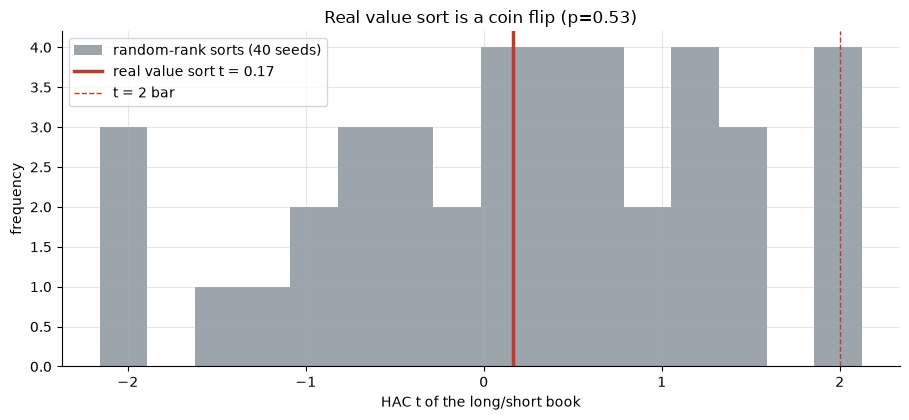

real t +0.17 | placebo mean t +0.22 (sd 1.11) | frac|t|>=2 8% | p 0.53


In [2]:
if HAVE_REAL:
    rep = st.value_report(PRICE, MRET)
    print(f"L/S: {rep['mean_bps']:+.2f} bps/mo (~{rep['ann_pct']:+.2f}%/yr) over "
          f"{rep['n_months']} months")
    print(f"HAC t = {rep['hac_t']:+.3f} ({rep['hac_lags']} lags) | one-sample t = "
          f"{rep['one_sample_t']:+.3f} | Sharpe {rep['sharpe']:+.3f} | hit {rep['hit_rate']*100:.1f}%")
    pl = st.random_placebo(PRICE, MRET); real_t, ts = pl['real_t'], pl['ts']
else:
    real_t = R['hac_t']
    ts = np.random.default_rng(793).normal(R['placebo_mean_t'], R['placebo_sd_t'], 40)
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.hist(ts, bins=16, color=GREY, alpha=.85, label='random-rank sorts (40 seeds)')
ax.axvline(real_t, c=RED, lw=2.5, label=f'real value sort t = {real_t:.2f}')
ax.axvline(2, ls='--', c=RED, lw=1, label='t = 2 bar')
ax.set_xlabel('HAC t of the long/short book'); ax.set_ylabel('frequency')
ax.set_title(f"Real value sort is a coin flip (p={R['placebo_p']:.2f})")
ax.legend(); plt.tight_layout(); plt.show()
print(f"real t {real_t:+.2f} | placebo mean t {R['placebo_mean_t']:+.2f} "
      f"(sd {R['placebo_sd_t']:.2f}) | frac|t|>=2 {R['placebo_frac_ge2']:.0%} | p {R['placebo_p']:.2f}")

> 💡 In plain words: the sort earns **+8 bps/mo** with **HAC t = 0.17** — a flat zero — and its *t* lands in the dead centre of the random-rank cloud (**p = 0.53**; the mean coin-flip actually beat it, 0.22 vs 0.17). **H₁ and H₂ both fail.** There is no premium here to certify — this is `NONE`, not a near-miss `WEAK`.

### 4b · Leg decomposition — the direction check

Each leg measured **excess of the equal-weight basket**. The value claim lives or dies on the **cheap (long) leg** being positive.

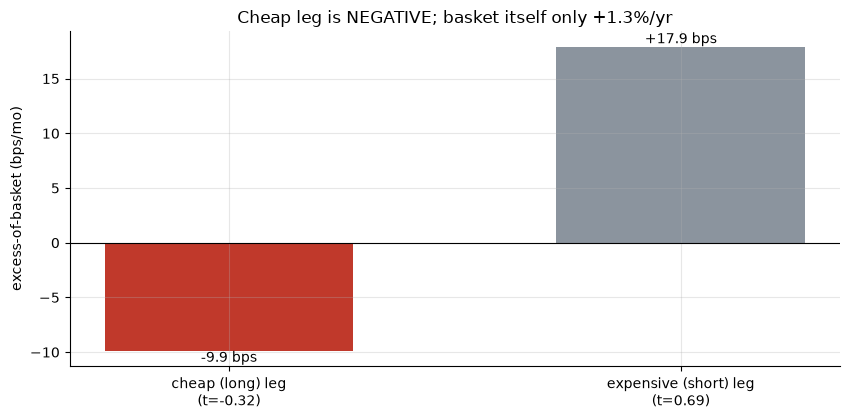

cheap (long) leg -9.88 bps (t=-0.32) | expensive (short) leg +17.93 bps (t=+0.69) | basket +1.29%/yr


In [3]:
if HAVE_REAL:
    lg = st.long_short_legs(PRICE, MRET)
    lb, sb, bt = lg['long_excess_bps'], lg['short_excess_bps'], lg['basket_ann_pct']
    lt, stt = lg['long_t'], lg['short_t']
else:
    lb, sb, bt = R['long_bps'], R['short_bps'], R['basket_ann']
    lt, stt = R['long_t'], R['short_t']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(['cheap (long) leg\n(t={:.2f})'.format(lt),'expensive (short) leg\n(t={:.2f})'.format(stt)],
       [lb, sb], color=[RED, GREY], width=.55)
for i,v in enumerate([lb, sb]): ax.annotate(f'{v:+.1f} bps',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('excess-of-basket (bps/mo)')
ax.set_title(f'Cheap leg is NEGATIVE; basket itself only {bt:+.1f}%/yr')
plt.tight_layout(); plt.show()
print(f'cheap (long) leg {lb:+.2f} bps (t={lt:+.2f}) | expensive (short) leg {sb:+.2f} bps (t={stt:+.2f}) | basket {bt:+.2f}%/yr')

> 💡 In plain words: the **cheap leg you bought lost 10 bps/mo to the basket** (t = -0.32) — the fallen commodities kept falling relative to the pack, the exact opposite of the value hypothesis. The short (expensive) leg added +18 bps/mo but is itself noise (t = 0.69). **H₃ fails, and not by a hair — the sign is wrong.** Whatever tiny L/S number exists is a short-side accident, not a value reversal.

### 4c · Persistence — was there ever a premium, in either half?

Split at 2019-07-01; within-era HAC *t* and a Welch *t* of the difference.

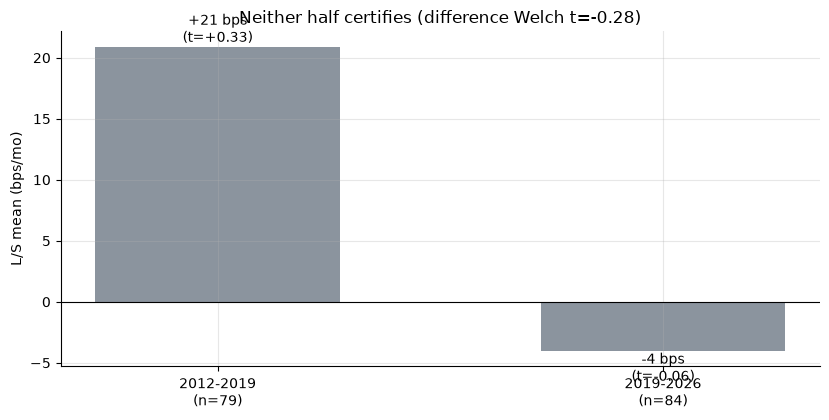

early +20.9 bps (t=+0.33) | late -4.1 bps (t=-0.06) | diff Welch t -0.28


In [4]:
if HAVE_REAL:
    sp = st.subperiod_contrast(PRICE, MRET, data.ERA_SPLIT)
    e_b, l_b = sp['early_bps'], sp['late_bps']
    e_t, l_t, d_t = sp['early_t'], sp['late_t'], sp['welch_t_diff']
else:
    e_b, l_b = R['early_bps'], R['late_bps']
    e_t, l_t, d_t = R['early_t'], R['late_t'], R['diff_t']
fig, ax = plt.subplots(figsize=(8.4, 4.3))
ax.bar(['2012-2019\n(n={})'.format(R['early_n']),'2019-2026\n(n={})'.format(R['late_n'])],
       [e_b, l_b], color=[GREY, GREY], width=.55)
for i,(v,t_) in enumerate([(e_b,e_t),(l_b,l_t)]):
    ax.annotate(f'{v:+.0f} bps\n(t={t_:+.2f})',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('L/S mean (bps/mo)')
ax.set_title(f'Neither half certifies (difference Welch t={d_t:+.2f})')
plt.tight_layout(); plt.show()
print(f'early {e_b:+.1f} bps (t={e_t:+.2f}) | late {l_b:+.1f} bps (t={l_t:+.2f}) | diff Welch t {d_t:+.2f}')

> 💡 In plain words: the early half is a weak +21 bps/mo (t = 0.33), the late half slightly *negative* (-4 bps/mo, t = -0.06); the difference is noise (Welch t = -0.28). This is **not a faded effect — it was never there** in either sub-period. There is nothing to decay.

### 4d · The costed timer — moot, but shown for completeness

One-way cost × traded notional; short leg pays 50 bps/yr borrow.

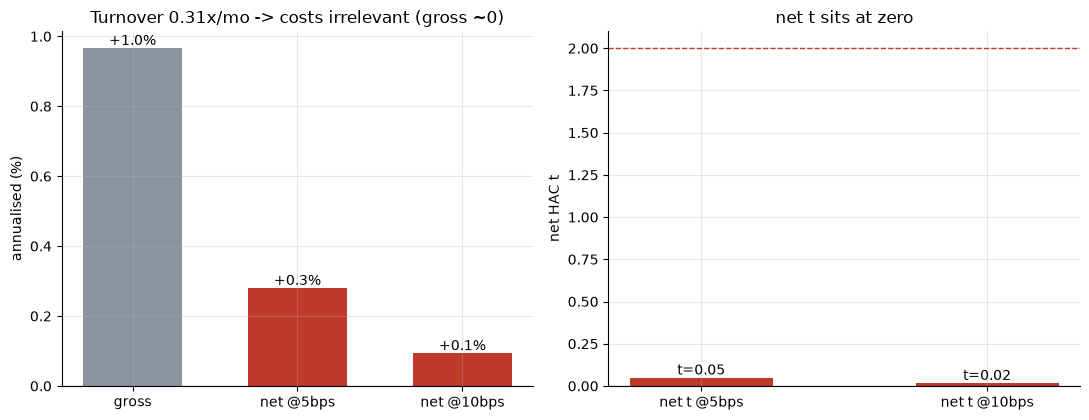

gross +1.0% -> net +0.3% (t=0.05) / +0.1% (t=0.02), turnover 0.31x


In [5]:
if HAVE_REAL:
    tm5 = st.costed_timer(PRICE, MRET, cost_bps=5.0)
    tm10 = st.costed_timer(PRICE, MRET, cost_bps=10.0)
    g = tm5['gross_ann_pct']; n5, n10 = tm5['net_ann_pct'], tm10['net_ann_pct']
    t5, t10 = tm5['net_t'], tm10['net_t']; to = tm5['avg_turnover']
else:
    g = R['timer5_gross']; n5, n10 = R['timer5_net'], R['timer10_net']
    t5, t10 = R['timer5_t'], R['timer10_t']; to = R['turnover']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar(['gross','net @5bps','net @10bps'], [g, n5, n10], color=[GREY, RED, RED], width=.6)
for i,v in enumerate([g, n5, n10]): a1.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('annualised (%)')
a1.set_title(f'Turnover {to:.2f}x/mo -> costs irrelevant (gross ~0)')
a2.bar(['net t @5bps','net t @10bps'], [t5, t10], color=[RED, RED], width=.5)
for i,v in enumerate([t5, t10]): a2.annotate(f't={v:.2f}',(i,v),ha='center',va='bottom')
a2.axhline(2, ls='--', c=RED, lw=1); a2.axhline(0, c='k', lw=.8)
a2.set_ylabel('net HAC t'); a2.set_title('net t sits at zero')
plt.tight_layout(); plt.show()
print(f'gross {g:+.1f}% -> net {n5:+.1f}% (t={t5:.2f}) / {n10:+.1f}% (t={t10:.2f}), turnover {to:.2f}x')

> 💡 In plain words: a 5-year signal barely trades (turnover **0.31× NAV/mo**), so costs are almost free — but the gross was already **~+1%/yr** with **net HAC t = 0.02**. **H₄ is moot: you can't lose a race you never started. → `MIRAGE`.**

### 4e · Faithful-engine & power control — we know the truth here

Synthetic random-walk **price** panel with a TUNABLE planted long-horizon reversal (`val_edge`). The null (`val_edge` = 0) is checked over **20 seeds** — never a single stream — so we know a `NONE` on the real tape is the *effect* being absent, not the detector being broken.

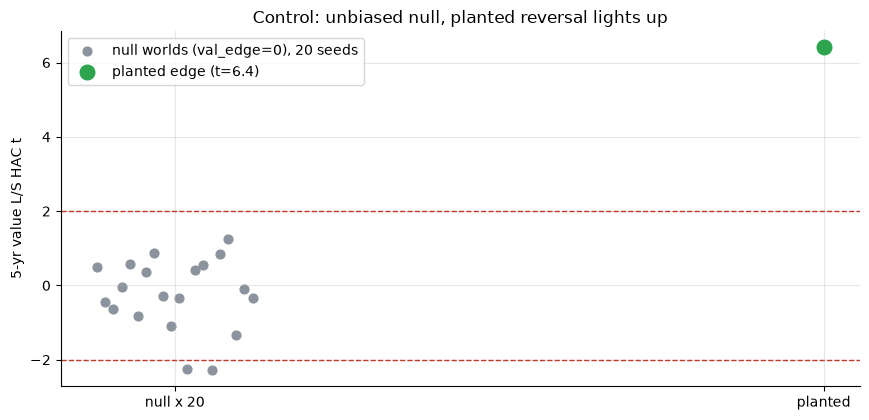

null: mean t -0.23 (sd 0.97), |t|>=2 in 2/20 | planted t +6.41


In [6]:
null_ts = np.array([st.synthetic_detect(data.synthetic_world(val_edge=0.0, seed=793+s))['hac_t']
                    for s in range(20)])
planted = st.synthetic_detect(data.synthetic_world(val_edge=0.05, seed=793))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (val_edge=0), 20 seeds')
ax.scatter([1], [planted['hac_t']], color=GREEN, s=110, zorder=5,
           label=f"planted edge (t={planted['hac_t']:.1f})")
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.set_xticks([0,1]); ax.set_xticklabels(['null x 20','planted'])
ax.set_ylabel('5-yr value L/S HAC t')
ax.set_title('Control: unbiased null, planted reversal lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 | planted t {planted["hac_t"]:+.2f}')

> 💡 In plain words: across 20 null (random-walk) worlds the detector averages t = -0.23 (unbiased) and fires |t| ≥ 2 on only 2/20 seeds — the ~5-10% false-positive rate you *expect* from noise. A planted reversal (`val_edge` = 0.05) reads t = 6.4 (+257 bps/mo). **The sort finds value when value is there; on the real tape it reads 0.17 — so the effect, not the machinery, is missing.** *(Machinery / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — 5-yr value L/S +8 bps/mo (~+1.0%/yr, Sharpe 0.05); **HAC t = 0.17**, indistinguishable from a random-rank sort (p = 0.53). Literature-backed (AMP 2013) in a broad spot-futures cross-section, but **this investable ETF tape shows no premium at all** — and survivorship + roll both bias the read upward, so even this zero is an upper bound.
- **Tradability `MIRAGE`** — net +0.1%/yr @10bps (net HAC t = 0.02); the gross was already ~0, so there is nothing to capture at any cost.
- **Reversal direction `REFUTED`** — the cheap (long) leg's excess-of-basket return is *negative* (-10 bps/mo, t = -0.32). The beaten-down commodities did not out-bounce the risen ones; if anything the sign runs the wrong way.

## 6 · Going further

- **Spot-futures tape:** AMP's premium is measured on roll-adjusted *spot* series; an ETF proxy injects roll drift (chronic-contango energy reads perennially 'cheap'). A continuous-futures value tape is the natural robustness extension — does the effect reappear once roll is cleaned out?
- **Bigger cross-section:** 13 ETFs is a thin sort (4-5 names per leg). A 20-30 commodity futures panel (the AMP breadth) would restore power the ETF era lacks.
- **Dedup map:** [792-commodity-momentum](../../792-commodity-momentum/) (the **opposite horizon** — 12-1 continuation — on the *same 13-ETF basket*, `WEAK`); [638-value-momentum-everywhere](../../638-value-momentum-everywhere/) (the mixed multi-asset value+momentum *combo*, commodities one blended sleeve). This study isolates the **commodity value leg alone**.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*